<a href="https://www.kaggle.com/code/sonawanelalitsunil/test-nations-cricket-matches-1877-25-ml-63-66?scriptVersionId=236525780" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cricket-match-dataset-test-nations-18772025/Cricket-all-teams-all-matches.csv


## Title:
Test Nations Cricket Matches (1877–2025)

## Description:
A historical dataset covering Test cricket matches played by Test nations from 1877 to 2025, including match results, dates, and team details.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/cricket-match-dataset-test-nations-18772025/Cricket-all-teams-all-matches.csv')

In [3]:
df.head()

,Team 1,Team 2,Winner,Margin,Ground,Match Date,Scorecard,Format
0,India,Pakistan,drawn,NaN,Bengaluru,"Dec 8-12, 2007",Test # 1852,Test
1,India,Pakistan,drawn,NaN,Eden Gardens,"Nov 30-Dec 4, 2007",Test # 1850,Test
2,India,Pakistan,India,6 wickets,Delhi,"Nov 22-26, 2007",Test # 1849,Test
3,Pakistan,India,Pakistan,341 runs,Karachi,"Jan 29-Feb 1, 2006",Test # 1783,Test
4,Pakistan,India,drawn,NaN,Faisalabad,"Jan 21-25, 2006",Test # 1782,Test


In [4]:
df.tail()

,Team 1,Team 2,Winner,Margin,Ground,Match Date,Scorecard,Format
7788,Australia,ICC World XI,Australia,210 runs,Sydney,"Oct 14-17, 2005",Test # 1768,Test
7789,Australia,ICC World XI,Australia,156 runs,Melbourne (Docklands),"Oct 9, 2005",ODI # 2284,ODI
7790,Australia,ICC World XI,Australia,55 runs,Melbourne (Docklands),"Oct 7, 2005",ODI # 2283,ODI
7791,Australia,ICC World XI,Australia,93 runs,Melbourne (Docklands),"Oct 5, 2005",ODI # 2282,ODI
7792,ICC World XI,West Indies,West Indies,72 runs,Lord's,"May 31, 2018",T20I # 666,T20I


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7793 entries, 0 to 7792
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Team 1      7793 non-null   object
 1   Team 2      7793 non-null   object
 2   Winner      7793 non-null   object
 3   Margin      6755 non-null   object
 4   Ground      7793 non-null   object
 5   Match Date  7793 non-null   object
 6   Scorecard   7793 non-null   object
 7   Format      7793 non-null   object
dtypes: object(8)
memory usage: 487.2+ KB


In [6]:
df.describe()

,Team 1,Team 2,Winner,Margin,Ground,Match Date,Scorecard,Format
count,7793,7793,7793,6755,7793,7793,7793,7793
unique,13,14,16,556,179,6921,7793,3
top,Australia,Pakistan,Australia,7 wickets,Sydney,"Jun 13, 1983",Test # 1852,ODI
freq,1200,1007,1121,543,296,4,1,4130


In [7]:
df.isnull().sum()

Team 1           0
Team 2           0
Winner           0
Margin        1038
Ground           0
Match Date       0
Scorecard        0
Format           0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Team 1        object
Team 2        object
Winner        object
Margin        object
Ground        object
Match Date    object
Scorecard     object
Format        object
dtype: object

In [10]:
df.shape

(7793, 8)

In [11]:
df.columns

Index(['Team 1', 'Team 2', 'Winner', 'Margin', 'Ground', 'Match Date',
       'Scorecard', 'Format'],
      dtype='object')

## Data visualizations

In [12]:
# Fix 'Match Date' that has ranges like 'Nov 30-Dec 4, 2007'
df['Match Date'] = df['Match Date'].str.split('-').str[0]  # take part before '-'

# Now safely convert to datetime
df['Match Date'] = pd.to_datetime(df['Match Date'], errors='coerce')

# If still any errors, drop them
df.dropna(subset=['Match Date'], inplace=True)


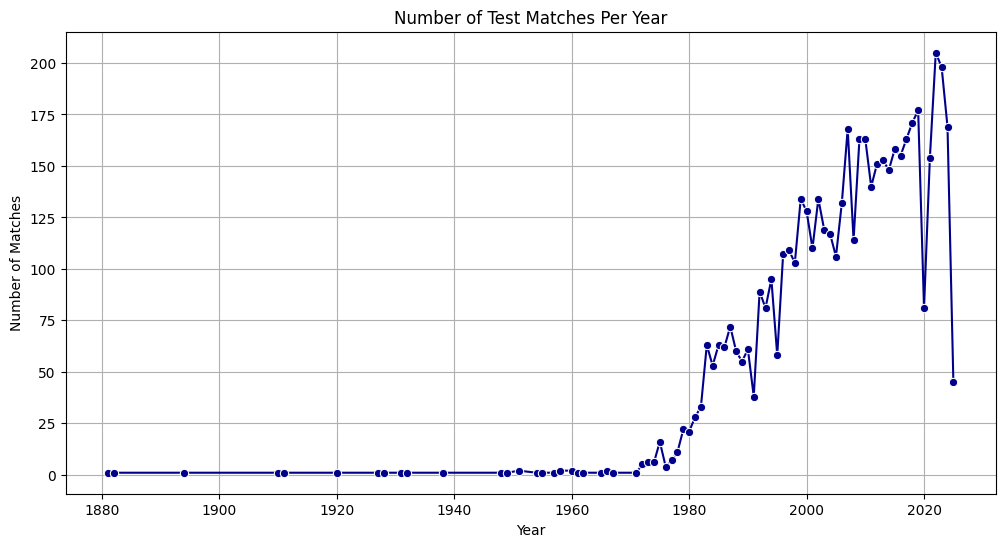

In [13]:
# Ensure 'Match Date' is datetime
df['Match Date'] = pd.to_datetime(df['Match Date'])

# 1. Matches Played Over Time
matches_per_year = df['Match Date'].dt.year.value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=matches_per_year.index, y=matches_per_year.values, marker="o", color='darkblue')
plt.title('Number of Test Matches Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Matches')
plt.grid(True)
plt.show()

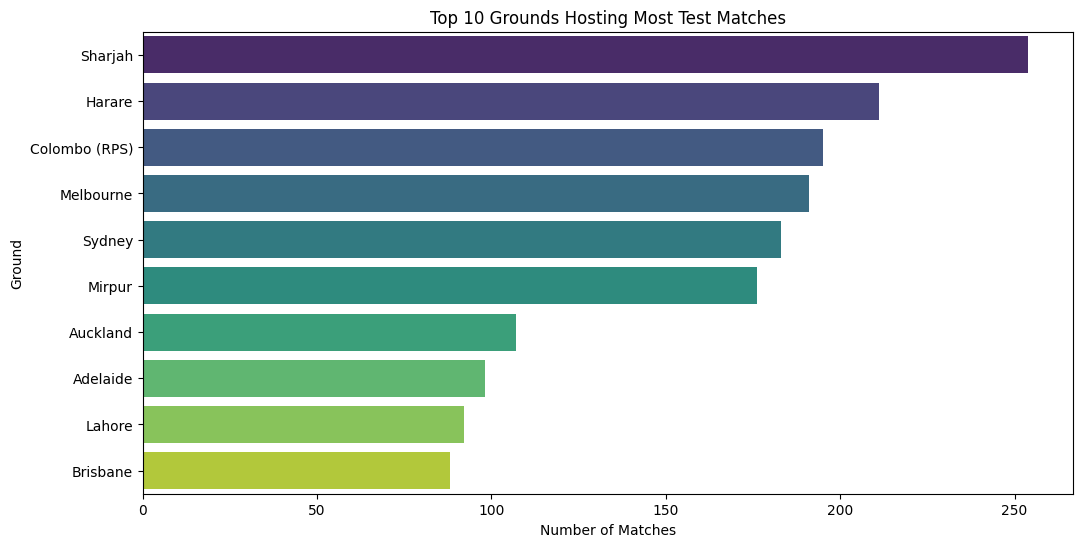

In [14]:
# 2. Top 10 Grounds by Number of Matches
top_grounds = df['Ground'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_grounds.values, y=top_grounds.index, palette="viridis")
plt.title('Top 10 Grounds Hosting Most Test Matches')
plt.xlabel('Number of Matches')
plt.ylabel('Ground')
plt.show()

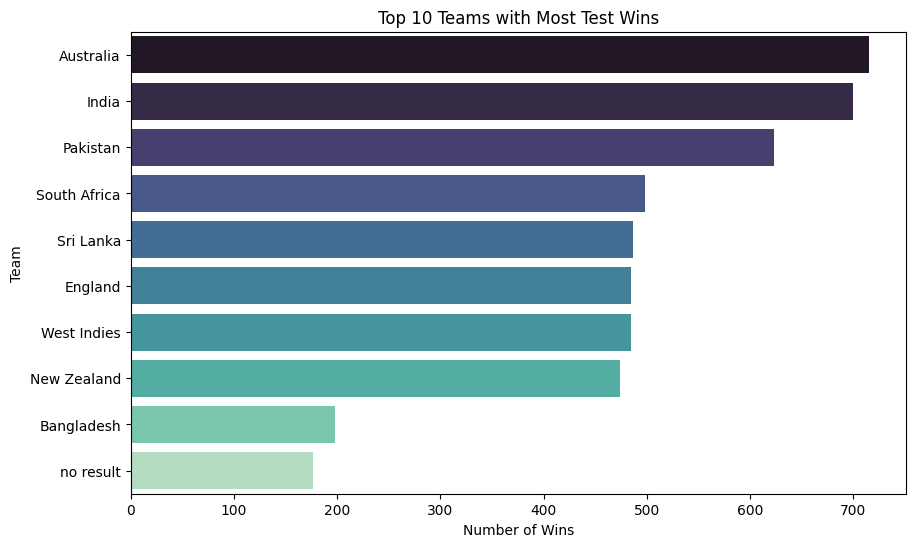

In [15]:
# 3. Top 10 Teams with Most Wins
top_winners = df['Winner'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_winners.values, y=top_winners.index, palette="mako")
plt.title('Top 10 Teams with Most Test Wins')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.show()

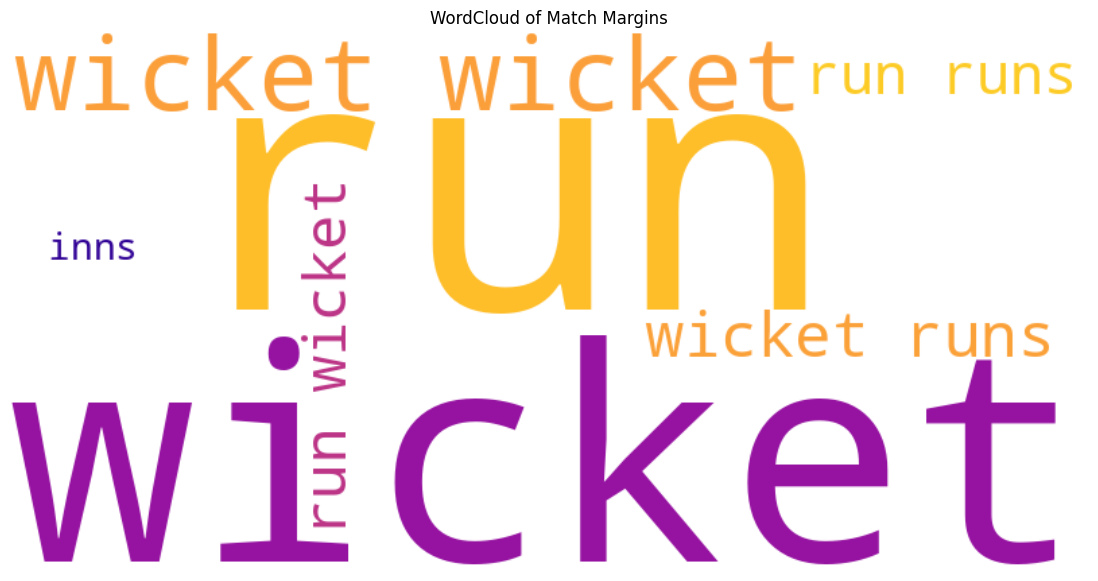

In [16]:
# 4. Match Results Margin Word Cloud
from wordcloud import WordCloud

text = " ".join(df['Margin'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Match Margins')
plt.show()

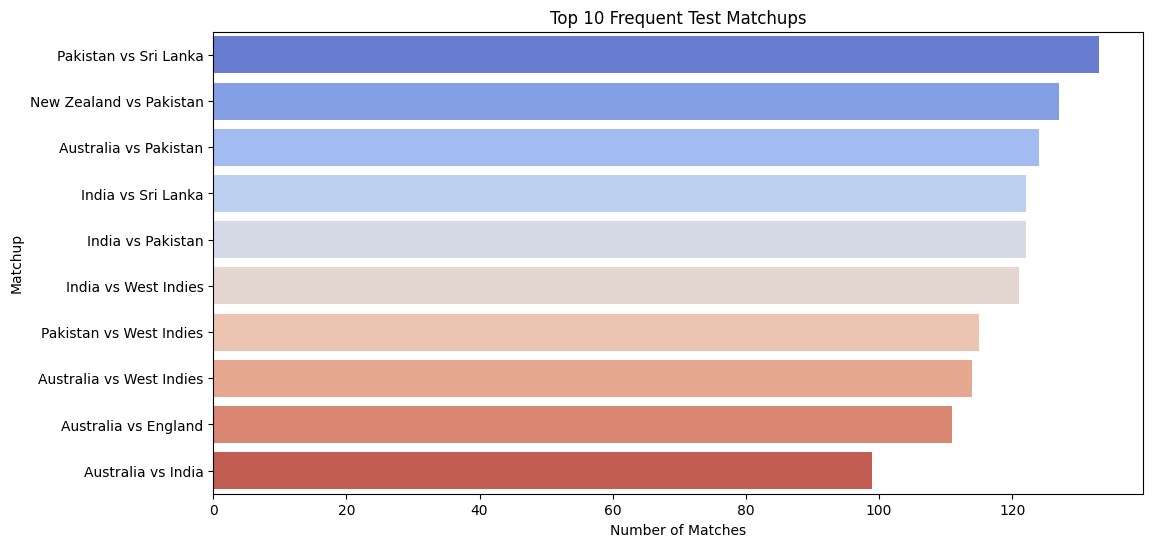

In [17]:
# 5. Most Frequent Matchups
matchups = df.groupby(['Team 1', 'Team 2']).size().reset_index(name='Matches')
matchups_sorted = matchups.sort_values('Matches', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x='Matches', y=matchups_sorted.apply(lambda x: f"{x['Team 1']} vs {x['Team 2']}", axis=1),
            data=matchups_sorted, palette="coolwarm")
plt.title('Top 10 Frequent Test Matchups')
plt.xlabel('Number of Matches')
plt.ylabel('Matchup')
plt.show()


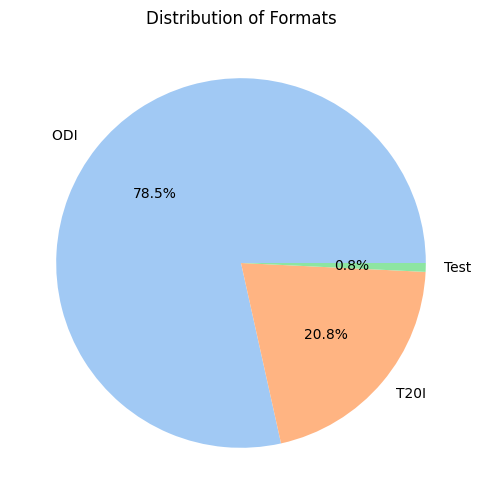

In [18]:
# 6. Format Distribution
format_counts = df['Format'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(format_counts, labels=format_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Distribution of Formats')
plt.show()

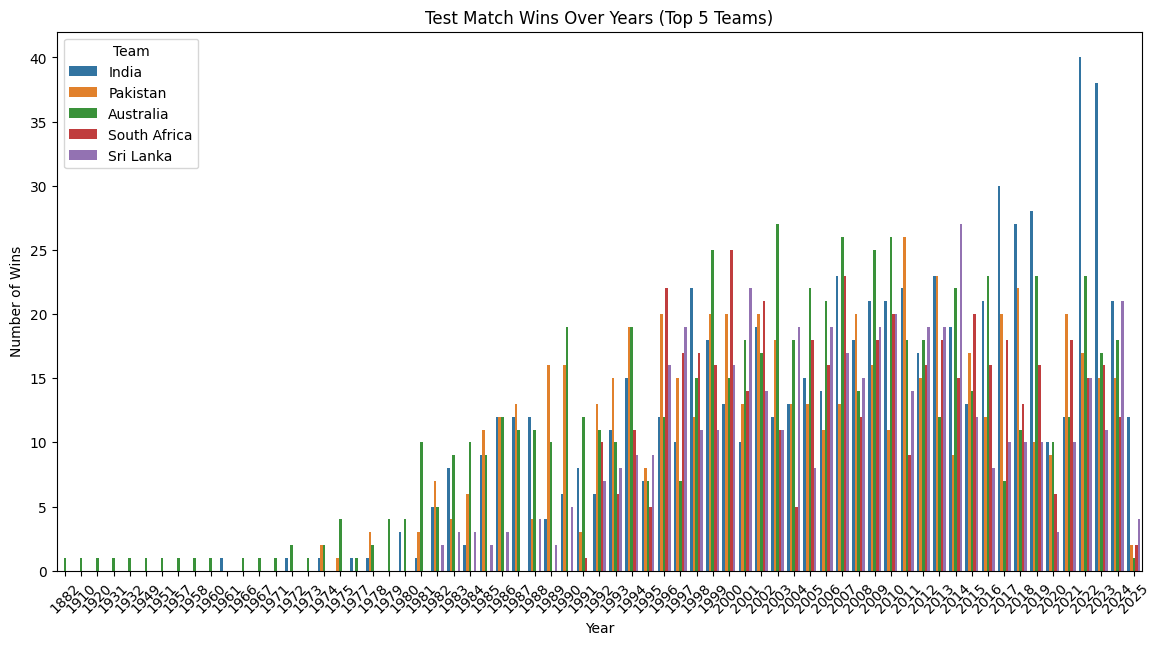

In [19]:
# 7. Timeline of Test Match Wins - Top 5 Teams
top5_teams = df['Winner'].value_counts().head(5).index.tolist()

df_top5 = df[df['Winner'].isin(top5_teams)]
df_top5['Year'] = df_top5['Match Date'].dt.year

plt.figure(figsize=(14,7))
sns.countplot(data=df_top5, x='Year', hue='Winner', palette='tab10')
plt.title('Test Match Wins Over Years (Top 5 Teams)')
plt.xlabel('Year')
plt.ylabel('Number of Wins')
plt.legend(title='Team')
plt.xticks(rotation=45)
plt.show()

## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [21]:
# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [22]:
# Drop 'Scorecard' (URL links usually not useful for ML)
df.drop('Scorecard', axis=1, inplace=True)

# Convert 'Match Date' to datetime
df['Match Date'] = pd.to_datetime(df['Match Date'])

# Extract Year, Month from Date (helpful features)
df['Year'] = df['Match Date'].dt.year
df['Month'] = df['Match Date'].dt.month

# Drop 'Match Date' after extracting features
df.drop('Match Date', axis=1, inplace=True)

# Handle missing values if any
df.fillna('Unknown', inplace=True)

# Label Encoding
le = LabelEncoder()
for col in ['Team 1', 'Team 2', 'Winner', 'Margin', 'Ground', 'Format']:
    df[col] = le.fit_transform(df[col])

# Define features and target
X = df.drop('Winner', axis=1)
y = df['Winner']


In [23]:
# Keep only winners that occur at least 2 times
winner_counts = df['Winner'].value_counts()
valid_winners = winner_counts[winner_counts > 1].index
df = df[df['Winner'].isin(valid_winners)]


In [24]:
# Split into train and test
# Remove stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Helper function to train and evaluate model
def train_evaluate(model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"{model_name} Accuracy: {acc:.2f}%")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

Logistic Regression Accuracy: 25.12%


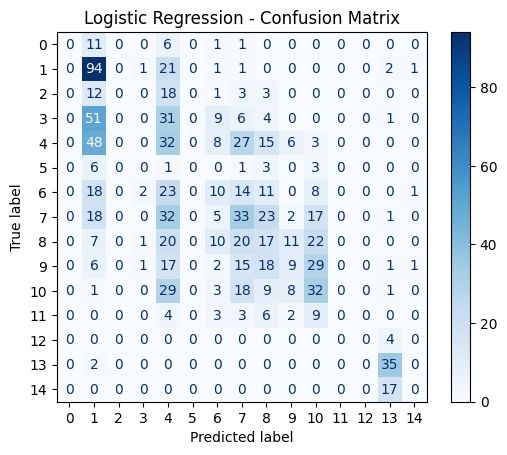

Decision Tree Accuracy: 56.95%


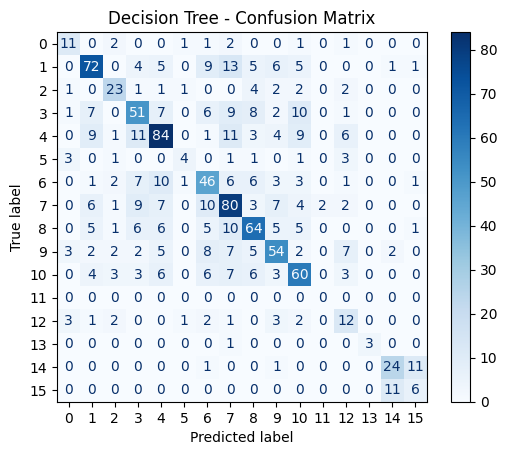

Random Forest Accuracy: 61.27%


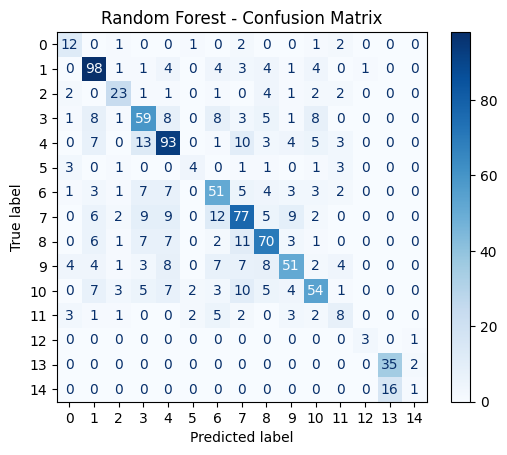

Gradient Boosting Accuracy: 63.66%


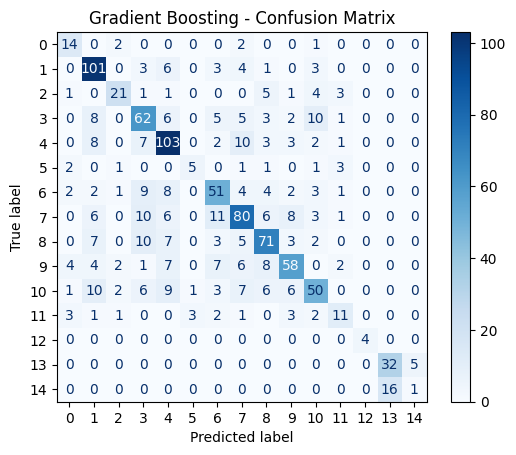

Support Vector Machine Accuracy: 11.60%


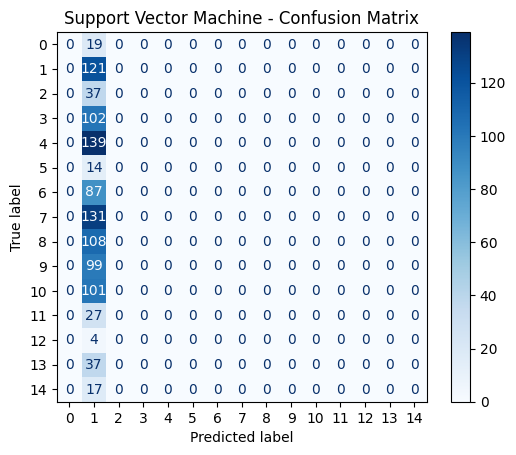

K-Nearest Neighbors Accuracy: 25.50%


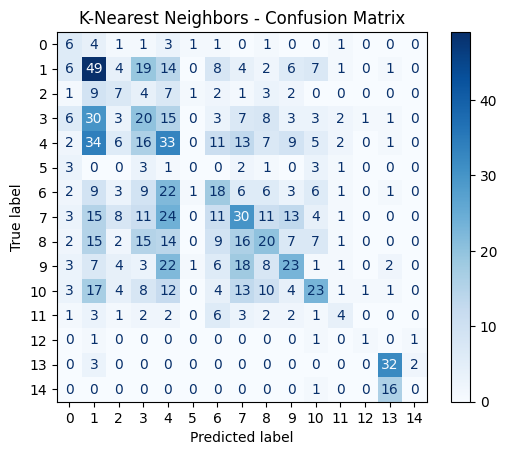

Naive Bayes Accuracy: 29.82%


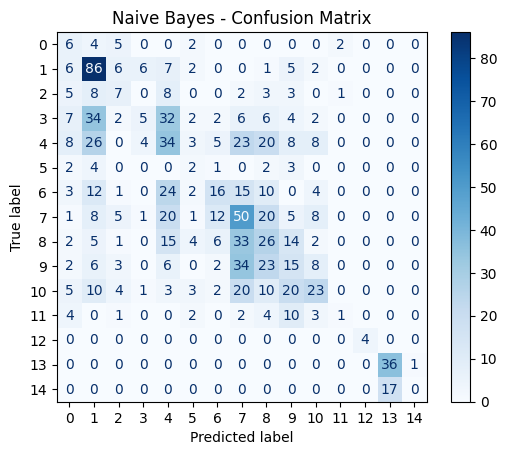

In [25]:
# Train and evaluate different models

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
train_evaluate(lr, "Logistic Regression")

# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
train_evaluate(dt, "Decision Tree")

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
train_evaluate(rf, "Random Forest")

# 4. Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
train_evaluate(gb, "Gradient Boosting")

# 5. Support Vector Machine (SVM)
svm = SVC()
train_evaluate(svm, "Support Vector Machine")

# 6. K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier()
train_evaluate(knn, "K-Nearest Neighbors")

# 7. Naive Bayes
nb = GaussianNB()
train_evaluate(nb, "Naive Bayes")

## Thank you.pls upvote!!!